Proses ini hanya digunakan sebagai visual validasi untuk menentukan batas atas dan bawah Bisection

Rentang Pencarian: [-0.5, 4.5]
Ditemukan 3 akar (zeros):
  Akar ke-1: x = -0.322001 | f(x) = -6.73e-05
  Akar ke-2: x = 0.346973 | f(x) = -3.02e-05
  Akar ke-3: x = 4.475032 | f(x) = 5.06e-06


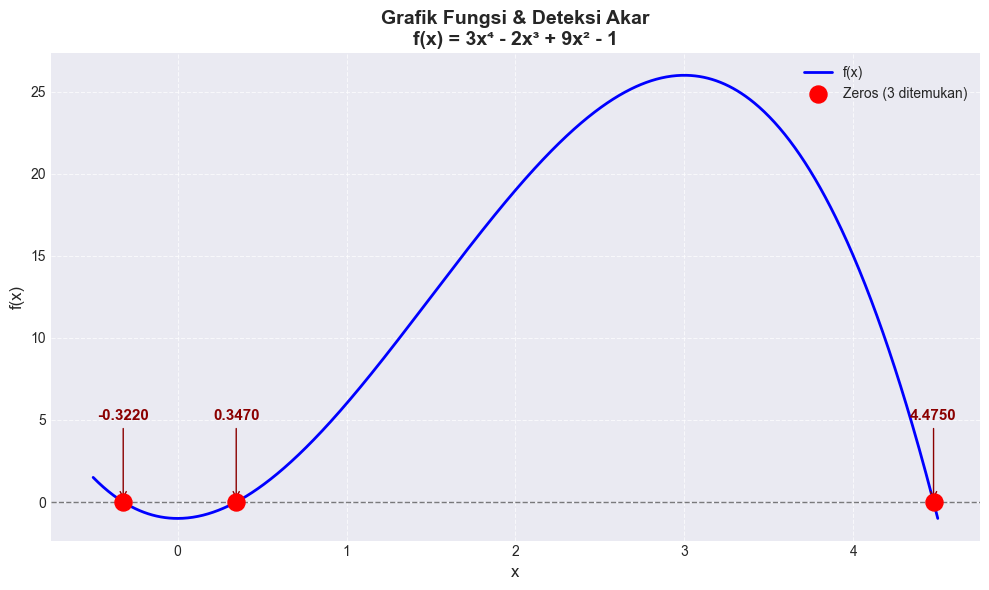

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Definisi Fungsi Non-Linear
def f(x):
    # Ubah rumus fungsi di bawah ini sesuai kebutuhan
    return - 2*x**3 + 9*x**2 - 1

# Konfigurasi batas nilai x dan data_points
x_min = -0.50
x_max = 4.50
num_points = 1000  # Semakin tinggi, semakin halus plot & deteksi akar

# Generate data
x = np.linspace(x_min, x_max, num_points)
y = f(x)

# Algoritma Pencarian Akar (menggunakan library)
# Proses ini digunakan untuk pembanding saja 
zeros_list = []

# Deteksi perubahan tanda (sign change) 
# Proses inti dari Bisection Method
sign_changes = np.where(np.diff(np.sign(y)))[0]

for i in sign_changes:
    x1, x2 = x[i], x[i+1]
    y1, y2 = y[i], y[i+1]
    
    # Hindari pembagian dengan nol jika y1 == y2
    if y2 - y1 != 0:
        # Interpolasi Linear untuk presisi
        x_root = x1 - y1 * (x2 - x1) / (y2 - y1)
        zeros_list.append(x_root)

# Hapus akar ganda (jika ada deteksi ganda)
unique_zeros = []
for z in zeros_list:
    if not any(abs(z - uz) < 1e-3 for uz in unique_zeros):
        unique_zeros.append(z)

# ==========================================
# FIX: KONVERSI KE NUMPY ARRAY
# ==========================================
# Ubah list menjadi numpy array agar bisa diproses oleh fungsi f(x)
zeros = np.array(unique_zeros)

# ==========================================
# 4. VISUALISASI
# ==========================================
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(10, 6))

# Plot Fungsi
ax.plot(x, y, label='f(x)', color='blue', linewidth=2)

# Plot Garis Y = 0
ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)

# Plot Titik Zeros
if len(zeros) > 0:
    zero_y = f(zeros)
    ax.scatter(zeros, zero_y, color='red', s=150, zorder=5, label=f'Zeros ({len(zeros)} ditemukan)')
    
    # Anotasi Nilai Akar
    for z in zeros:
        ax.annotate(f'{z:.4f}', 
                    xy=(z, 0), 
                    xytext=(z, f(z) + 5), 
                    horizontalalignment='center',
                    fontsize=11,
                    color='darkred',
                    weight='bold',
                    arrowprops=dict(arrowstyle='->', color='darkred'))
else:
    print("Tidak ada akar yang ditemukan dalam rentang ini.")

# Dekorasi plot supaya mudah dibaca
ax.set_title(f'Grafik Fungsi & Deteksi Akar\nf(x) = 3x⁴ - 2x³ + 9x² - 1', fontsize=14, fontweight='bold')
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('f(x)', fontsize=12)
ax.legend(loc='best')
ax.grid(True, linestyle='--', alpha=0.7)

print("Proses ini hanya digunakan sebagai visual validasi untuk menentukan batas atas dan bawah Bisection\n")
print("="*50)
print(f"Rentang Pencarian: [{x_min}, {x_max}]")
print("="*50)
if len(zeros) > 0:
    print(f"Ditemukan {len(zeros)} akar (zeros):")
    for i, z in enumerate(zeros, 1):
        print(f"  Akar ke-{i}: x = {z:.6f} | f(x) = {f(z):.2e}")
else:
    print("Tidak ada akar riil dalam rentang tersebut.")
print("="*50)

plt.tight_layout()
plt.show()

# Bisection Methods

Metode ini adalah metode pencarian akar yang cukup sederhana, di mana proses intinya yaitu melakukan halfing interval pada dua fungsi yang saling berlawanan nilainya. Contoh: ada 2 fungsi yang nilainya berbeda, fungsi pertama bernilai -2.15 dan fungsi kedua bernilai 5.25, maka Bisection's Method dapat dilakukan untuk mencari akar diantara nilai x dari kedua fungsi tersebut.

## Metode Pencarian

Dalam tugas ini saya membuat dua metode pencarian, 
- 1. Metode tolerance atau sesuai nilai absolute error (abs) tanpa memedulikan jumlah iterasi. 
- 2. Metode dengan jumlah iterasi tanpa memedulikan berapa nilai tolerancenya atau nilai absolute errornya.

In [16]:
def bisection(a, b, tol=1e-6, max_iter=100, mode='tolerance'):
    """
    Metode Bisection dengan 2 mode:
    - mode='tolerance'  -> berhenti saat error < tol
    - mode='iteration'  -> berhenti setelah max_iter iterasi
    """
    fa = f(a)
    fb = f(b)
    
    if fa * fb >= 0:
        print(f"f({a}) = {fa}, f({b}) = {fb}")
        print("Error: Interval tidak valid! f(a) dan f(b) harus berlawanan tanda.")
        return None, 0
    
    iterasi = 0
    
    print(f"{'Iterasi':<6} {'a':<15} {'b':<15} {'c':<15} {'f(c)':<15} {'Error':<15}")
    print("-" * 75)
    
    while True:
        iterasi += 1
        
        # Interval halving
        c = (a + b) / 2
        fc = f(c)
        error = abs(b - a) / 2
        
        print(f"{iterasi:<6} {a:<15.8f} {b:<15.8f} {c:<15.8f} {fc:<15.8f} {error:<15.2e}")
        
        if mode == 'tolerance' and error < tol:
            break
        elif mode == 'iteration' and iterasi >= max_iter:
            break
        
        # Update interval
        if fa * fc < 0:
            b = c
            fb = fc
        else:
            a = c
            fa = fc
    
    return c, iterasi

In [17]:
def bisection(a, b, tol=1e-6, max_iter=100, mode='tolerance'):
    """
    Metode Bisection dengan 2 mode:
    - mode='tolerance'  -> berhenti saat error < tol
    - mode='iteration'  -> berhenti setelah max_iter iterasi
    """
    fa = f(a)
    fb = f(b)
    
    if fa * fb >= 0:
        print(f"f({a}) = {fa}, f({b}) = {fb}")
        print("Error: Interval tidak valid! f(a) dan f(b) harus berlawanan tanda.")
        return None, 0
    
    iterasi = 0
    
    print(f"{'Iterasi':<6} {'a':<15} {'b':<15} {'c':<15} {'f(c)':<15} {'Error':<15}")
    print("-" * 75)
    
    while True:
        iterasi += 1
        
        # Interval halving
        c = (a + b) / 2
        fc = f(c)
        error = abs(b - a) / 2
        
        print(f"{iterasi:<6} {a:<15.8f} {b:<15.8f} {c:<15.8f} {fc:<15.8f} {error:<15.2e}")
        
        if mode == 'tolerance' and error < tol:
            break
        elif mode == 'iteration' and iterasi >= max_iter:
            break
        
        # Update interval
        if fa * fc < 0:
            b = c
            fb = fc
        else:
            a = c
            fa = fc
    
    return c, iterasi

In [18]:
# Mode 1: Berdasarkan toleransi
print("\nMODE 1 - Toleransi:\n")
root1, iter1 = bisection(4, 5, tol=1e-6, mode='tolerance')
if root1 is not None:
    print(f"\nAkar: {root1:.10f}")
    print(f"Iterasi: {iter1}")
    print(f"f(x): {f(root1):.2e}\n")


MODE 1 - Toleransi:

Iterasi a               b               c               f(c)            Error          
---------------------------------------------------------------------------
1      4.00000000      5.00000000      4.50000000      -1.00000000     5.00e-01       
2      4.00000000      4.50000000      4.25000000      8.03125000      2.50e-01       
3      4.25000000      4.50000000      4.37500000      3.78515625      1.25e-01       
4      4.37500000      4.50000000      4.43750000      1.46142578      6.25e-02       
5      4.43750000      4.50000000      4.46875000      0.24810791      3.12e-02       
6      4.46875000      4.50000000      4.48437500      -0.37157440     1.56e-02       
7      4.46875000      4.48437500      4.47656250      -0.06064320     7.81e-03       
8      4.46875000      4.47656250      4.47265625      0.09400451      3.91e-03       
9      4.47265625      4.47656250      4.47460938      0.01674874      1.95e-03       
10     4.47460938      4.476562

In [19]:
# Mode 2: Berdasarkan jumlah iterasi
print("MODE 2 - 10 Iterasi:\n")
root2, iter2 = bisection(4, 5, max_iter=30, mode='iteration')
if root2 is not None:
    print(f"\nAkar: {root2:.10f}")
    print(f"Iterasi: {iter2}")
    print(f"f(x): {f(root2):.2e}")

MODE 2 - 10 Iterasi:

Iterasi a               b               c               f(c)            Error          
---------------------------------------------------------------------------
1      4.00000000      5.00000000      4.50000000      -1.00000000     5.00e-01       
2      4.00000000      4.50000000      4.25000000      8.03125000      2.50e-01       
3      4.25000000      4.50000000      4.37500000      3.78515625      1.25e-01       
4      4.37500000      4.50000000      4.43750000      1.46142578      6.25e-02       
5      4.43750000      4.50000000      4.46875000      0.24810791      3.12e-02       
6      4.46875000      4.50000000      4.48437500      -0.37157440     1.56e-02       
7      4.46875000      4.48437500      4.47656250      -0.06064320     7.81e-03       
8      4.46875000      4.47656250      4.47265625      0.09400451      3.91e-03       
9      4.47265625      4.47656250      4.47460938      0.01674874      1.95e-03       
10     4.47460938      4.476562